# 2.Pytroch基础

In [ ]:
# 测试是否导入pytorch环境
import torch
print(torch.__version__)

## 2.4 Numpy和Tensor

Tensor和Numpy相似，两者可以共享内存，且之间的转换方便和高效。Numpy会将ndarray放在CPU进行加速运算，而Torch产生的Tensor会放在GPU加速运算

### 2.4.1 Tensor概述
- 从接口角度可以对Tensor划分为两类：  
1)torch.function,如torch.sum、torch.add等  
2)tensor.function,如tensor.view、tensor.add等  
torch.add(x,y)等价于x.add(y)  
- 从修改方式角度来划分为两类：
1)x.add(y)，x的数据不变，返回一个新的Tensor
2)x.add_(y)，运行结果存在x中，x被修改

In [ ]:
import torch

x =  torch.tensor([1,2])
y = torch.tensor([3,4])
z = x.add(y)
print('z = x.add(y):', z)
print('x:', x)

x.add_(y)
print('x.add_(y):', x)

### 2.4.2 创建Tensor

常见的创建Tensor方法  
|函数|功能|
|:---:|:---:|
|Tensor(*size)|直接从参数构造一个的张量，支持List、Numpy数组|
|eye(row, column)|创建指定行数、列数的二维单位Tensor|
|linspace(start,end,steps)|从start到end，均匀切分成steps份|
|logspace(start,end,steps)|从10^start，到10……end，均匀切分乘steps份|
|rand/randn(*size)|生成[0,1)均匀分布/标准正态分布数据|
|ones(*size)|返回指定shape的张量，元素初始为1|
|zeros(*size)|返回指定shape的张量，元素初始为0|
|ones_like(t)|返回与T的shape相同的张量，且元素初始为1|
|zeros_like(t)|返回与T的shape相同的张量，且元素初始为0|
|arange(start,end,step)|在区间[start,end)上以间隔step生成一个序列张量|
|from_Numpy(ndarry)|从ndarry创建一个Tensor|

In [ ]:
print(torch.Tensor([1,2,3,4,5,6])) # 根据list数据生成Tensor
print(torch.Tensor(2,3)) # 根据指定形状生成Tensor
t = torch.Tensor([[1,2,3],[4,5,6]]) # 指定给定的Tensor的形状
print(t.size())
print(t.shape) # shape与size()的等价方式
print(torch.Tensor(t.size())) # 根据已有形状创建Tensor

In [ ]:
# torch.Tensor(n) 是 PyTorch 中创建形状为 (n,) 的一维张量
t1 = torch.Tensor(1) # 返回一个大小为1的张量，其中是随机初始化的值
t2 = torch.tensor(1) # 返回固定值1
print(f't1的值{t1},t1的数据类型{t1.type()}')
print(f't2的值{t2},t2的数据类型{t2.type()}') 

In [ ]:
print('生成一个单位矩阵', torch.eye(2,2)) # 生成一个单位矩阵
print('生成一个全0矩阵', torch.zeros(2,3)) # 生成一个全0矩阵
print('根据规则生成数据', torch.linspace(1,10,4)) # 根据规则生成数据
print('生成满足均匀分布随机数矩阵', torch.rand(2,3)) # 生成满足均匀分布随机数矩阵
print('生成满足标准分布随机数矩阵', torch.randn(2,3)) # 生成满足标准正态分布随机数矩阵
print('生成与其形状相同的全零矩阵', torch.zeros_like(torch.rand(2,3))) # 生成与其形状相同的全零矩阵

### 2.4.3 修改Tensor形状

经常需要了解Tensor的形状、修改Tensor形状，修改Tensor也有很多函数
|函数|说明|
|:---:|:---:|
|size()|返回张量的shape属性值，与函数shape等价|
|numel(input)|计算Tensor的元素个数|
|view(*shape)|【修改Tensor的shape，View返回的对象与源Tensor共享内存】【修改一个另一个同时修改，Reshape将生成新的Tensor,而且不要求源Tensor是连续的】【View(-1)将展平数组】|
|resize|类似view，但是size超出时会重新分配内存空间|
|item|若Tensor为单元素，则返回Python的标量|
|unsqueeze|在指定维度增加一个'1'|
|squeeze|在指定维度压缩一个'1'|

In [ ]:
# 生成一个2x3矩阵
x = torch.randn(2,3)
# 查看矩阵形状
print(x.size())
# 查看x的维度
print(x.dim())
# 把x变为3x2的矩阵
print('x(2,3)——', x)
print('x(3,2)——', x.view(3,2))
# 把x展平为1维向量
y = x.view(-1)
print(y)
print(y.shape)
# 添加一个维度
z = torch.unsqueeze(y, 0)
print(z.size())
# 计算z的元素个数
print(z.numel())

### 2.4.4 索引操作

|函数|说明|
|:---:|:---:|
|index_select(input, dim, index)|在指定维度上选择一些行或列|
|nonzero(input)|获取非0元素的下标|
|masked_select(input,mask)|使用二元值进行选择|
|gather(input,dim,index)|在指定维度上选择数据，输出的形状与index一致|
|scatter_(input,dim,index,src)|为gather的反操作，根据指定索引补充数据|

In [ ]:
import torch
torch.manual_seed(100) # 设置一个随机种子
x = torch.randn(2, 3)
print(x)
print(x[0,:])
print(x[:,-1])
print(torch.masked_select(x,x > 0)) # 获取大于0的值
print(torch.nonzero(x>0)) # 返回一个装有坐标的Tensor列表


# index 按索引取值 gather 按索引赋值
index= torch.LongTensor([[0,1,1],[1,1,1]]) # LongTensor 取值范围[-2^63,2^63 -1]。PyTorch 中所有 “按索引取值 / 赋值” 的操作索引必须是 LongTensor 类
print('index',index)


a = torch.gather(x,1,index) # dim=1：按照列维度取值， a[i,j] = x[i,index(i,j)]
# a[0,0]=x[0,0]   a[0,1]=x[0,1]   a[0,2]=x[0,1]
# a[1,0]=x[1,1]   a[1,1]=x[1,1]   a[1,2]=x[1,1]

z = torch.zeros(2,3)


print(z.scatter_(1, index, a)) # 在指定dim=1列维度上，把源张量a的值，按照index索引值，赋予到张量z对应的位置上 z[i, index(i,j)] = a[i,j]
# z[0,index[0,0]=0] = a[0,0] z[0,index[0,1]=1]=a[0,1] z[0,index[0,2]=1]=a[0,2] 即z[0,1]=a[0,1]=a[0,2]=x[0,1]=-0.2859
# z[1,index[1,0]=1] = a[1,0] 以此类推......

### 2.4.5 广播机制
torch中的广播机制

In [ ]:
import torch
import numpy as np

A = np.arange(0, 40, 10).reshape(4,1)
print(A)

B = np.arange(0, 3)
print(B)

A1 = torch.from_numpy(A)
print(A1)
B1 = torch.from_numpy(B)
print(B1)

C = A1+B1
print(C)

B2 = B1.unsqueeze(0)
print(B2) # B1 [0, 1, 2] → B2 [[0, 1, 2]]

A2 = A1.expand(4,3)
print(A2)
B3 = B2.expand(4, 3)
print(B3)
C1 = A2 + B3
print(C1)

### 2.4.6 逐元素操作
| 函数          | 说明                                   |
|---------------|----------------------------------------|
| `abs/add`     | 绝对值 / 加法                          |
| `addcdiv(t, t1, t2, value=v)` | t1 与 t2 的按元素除后，乘 v 加 t        |
| `addcmul(t, t1, t2, value=v)` | t1 与 t2 的按元素乘后，乘 v 加 t        |
| `ceil/floor`  | 向上取整 / 向下取整                    |
| `clamp(t, min, max)` | 将张量元素限制在指定区间                |
| `exp/log/pow` | 指数 / 对数 / 幂                       |
| `mul(或 *)/neg` | 逐元素乘法 / 取反                      |
| `sigmoid/tanh/softmax` | 激活函数                               |
| `sign/sqrt`   | 取符号 / 开根号                        |

In [32]:
import torch

t = torch.randn(1, 3)
t1 = torch.randn(3, 1)
t2 = torch.randn(1, 3)

print(t)

print(torch.addcdiv(t, t1, t2, value=0.1))

print(torch.sigmoid(t))

print(torch.clamp(t, 0, 1)) # 将元素设置在一定区间

t.add_(2)

tensor([[-1.5035, -1.2893,  0.7983]])
tensor([[-1.5613, -1.9269,  1.1673],
        [-1.5439, -1.7351,  1.0563],
        [-1.5575, -1.8859,  1.1435]])
tensor([[0.1819, 0.2160, 0.6896]])
tensor([[0.0000, 0.0000, 0.7983]])


tensor([[0.4965, 0.7107, 2.7983]])

### 2.4.7 归并操作
| 函数              | 说明                               |
|-------------------|------------------------------------|
| `cumprod(t, axis)`| 在指定维度对 t 进行累积             |
| `cumsum`          | 在指定维度对 t 进行累加             |
| `dist(a, b, p=2)` | 返回 a, b 之间的 p 阶范数           |
| `mean/median`     | 均值 / 中位数                       |
| `std/var`         | 标准差 / 方差                       |
| `norm(t, p=2)`    | 返回 t 的 p 阶范数                  |
| `prod(t)/sum(t)`  | 返回 t 所有元素的积 / 和            |

In [38]:
a = torch.linspace(0, 10, 6)
print(a)
a = a.view((2,3))
print(a)
b = a.sum(dim=0) # 按行进行累加
print(b)
b = a.sum(dim=0, keepdim=True) # 维度与原张量一致
print(b)

tensor([ 0.,  2.,  4.,  6.,  8., 10.])
tensor([[ 0.,  2.,  4.],
        [ 6.,  8., 10.]])
tensor([ 6., 10., 14.])
tensor([[ 6., 10., 14.]])


### 2.4.8 比较操作

| 函数           | 说明                                               |
|----------------|----------------------------------------------------|
| `eq`           | 比较 Tensor 是否相等，支持 broadcast                |
| `equal`        | 比较 Tensor 是否有相同的 shape 与值                 |
| `ge/le/gt/lt`  | 大于 / 小于比较 / 大于等于 / 小于等于比较           |
| `max/min(t,axis)` | 返回最值，若指定 axis，则额外返回下标               |
| `topk(t,k,axis)`   | 在指定的 axis 维上取最高的 K 个值                  |

In [42]:
x = torch.linspace(0, 10, 6).view(2, 3)
print(x)
print(torch.max(x))
print(torch.max(x, dim=0))

tensor([[ 0.,  2.,  4.],
        [ 6.,  8., 10.]])
tensor(10.)
torch.return_types.max(
values=tensor([ 6.,  8., 10.]),
indices=tensor([1, 1, 1]))


### 2.4.9 矩阵操作

| 函数 | 说明 |
| ---- | ---- |
| dot(t1, t2) | 计算张量(1D)的内积或点积 |
| mm(mat1, mat2)/bmm(batch1, batch2) | 计算矩阵乘法/含batch的3D矩阵乘法 |
| mv(t1, v1) | 计算矩阵与向量乘法 |
| t | 转置 |
| svd(t) | 计算t的SVD分解 |

In [ ]:
import torch

a = torch.tensor([2, 3])
b = torch.tensor([3, 4])

print(torch.dot(a, b)) # 2*3 + 3*4 = 18


x = torch.randint(10, (2,3))
print('x',x)
y = torch.randint(6, (3,4))
print('y',y)

print(torch.mm(x,y)) # 矩阵乘法
x = torch.randint(10, (2,3,3)) # 等价于x = torch.randint(low=0, high=10, size=(2,3,3))
print('x',x)
y = torch.randint(6, (2,3,4))
print('y',y)
print(torch.bmm(x, y)) # 3D矩阵乘法

tensor(18)
x tensor([[6, 4, 6],
        [6, 5, 8]])
y tensor([[0, 1, 5, 2],
        [5, 3, 5, 2],
        [2, 3, 4, 0]])
tensor([[32, 36, 74, 20],
        [41, 45, 87, 22]])
x tensor([[[3, 2, 3],
         [2, 1, 8],
         [6, 5, 4]],

        [[1, 1, 3],
         [9, 4, 7],
         [6, 6, 5]]])
y tensor([[[1, 0, 4, 4],
         [2, 1, 1, 3],
         [1, 2, 0, 3]],

        [[2, 1, 1, 1],
         [2, 3, 0, 5],
         [2, 3, 0, 5]]])
tensor([[[10,  8, 14, 27],
         [12, 17,  9, 35],
         [20, 13, 29, 51]],

        [[10, 13,  1, 21],
         [40, 42,  9, 64],
         [34, 39,  6, 61]]])


### 2.4.10 PyTorch与Numpy的比较

| 操作类别     | Numpy                                      | PyTorch                                                  |
|--------------|--------------------------------------------|----------------------------------------------------------|
| 数据类型     | `np.ndarray`                               | `torch.Tensor`                                           |
|              | `np.float32`                                | `torch.float32; torch.float`                             |
|              | `np.float64`                                | `torch.float64; torch.double`                            |
|              | `np.int64`                                  | `torch.int64; torch.long`                                |
| 从已有数据构建 | `np.array([3.2, 4.3], dtype=np.float16)`   | `torch.tensor([3.2, 4.3], dtype=torch.float16)`          |
|              | `x.copy()`                                 | `x.clone()`                                              |
| 线性代数     | `np.dot`                                   | `torch.mm`                                               |
|              | `np.concatenate`                           | `torch.cat`                                              |
| 属性         | `x.ndim`                                   | `x.dim()`                                                |
|              | `x.size`                                   | `x.nelement()`                                           |
| 形状操作     | `x.reshape`                                | `x.reshape; x.view`                                      |
|              | `x.flatten`                                | `x.view(-1)`                                             |
| 类型转换     | `np.floor(x)`                              | `torch.floor(x); x.floor()`                              |
| 比较         | `np.less`                                  | `x.lt`                                                   |
|              | `np.less_equal/np.greater`                  | `x.le/x.gt`                                              |
|              | `np.greater_equal/np.equal/np.not_equal`    | `x.ge/x.eq/x.ne`                                         |
| 随机种子     | `np.random.seed`                           | `torch.manual_seed`                                     |

## 2.5 Tensor 和 Autograd

### 2.5.3 标量反向传播
z.backward()只能使用一次，第二次使用就会报错  

In [57]:
import torch
x = torch.Tensor([2])

w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

y = torch.mul(w, x)
z = torch.add(y, b) # z = wx + b

print(f'w,x,b的require_grad属性分别为{w.requires_grad},{x.requires_grad},{b.requires_grad}') # ∂z/∂w = ∂(xw)/∂w = ∂(2w)/∂w = 2诸如此类
print(f'y,z的require_grad属性分别为{y.requires_grad},{z.requires_grad}') # 因yz与wb有依赖关系故也有requires_grad属性

# 叶子节点——由用户亲自创建，非叶子节点——不由用户亲自创建 可以用x.is_leaf返回判断
# 非叶子节点中grad_fn记录了生成他的运算，如 MulBackward0, AddBackward0

print(z.backward()) # 执行backward后计算图自动清空，若多次使用则需设置retain_graph=True
print(w.grad, 'x.grad', b.grad) # x为叶子节点，但是requires_grad=False
# print(y.grad, z.grad) 错误，因为yz是非叶子节点 

w,x,b的require_grad属性分别为True,False,True
y,z的require_grad属性分别为True,True
None
tensor([2.]) x.grad tensor([1.])


### 2.5.4 非标量反向传播
PyTorch 只支持「标量对张量求导」，不支持「张量对张量求导」，所以必须用一个 gradient 张量把 “非标量输出” 加权成标量深度学习只需要标量损失求导
- 深度学习只需要标量损失求导
- 张量对张量求导（雅可比）太费显存、没用
- PyTorch 只实现真实需要的功能
- 所以必须把张量输出变成标量才能 .backward()
- gradient 就是用来做这件事的

In [6]:
import torch

x = torch.tensor([[2, 3]], dtype=torch.float, requires_grad=True)

J = torch.zeros(2,2)

y = torch.zeros(1,2)

# y1 = x1**2+3*x2, y2 = x2**2+2*x1
y[0, 0] = x[0, 0] ** 2 + 3 * x[0, 1]
y[0, 1] = x[0, 1] ** 2 + 2 * x[0, 0]

y.backward(torch.Tensor([[1, 0]]), retain_graph=True)
J[0] = x.grad
x.grad = torch.zeros_like(x.grad)

y.backward(torch.Tensor([[0, 1]]))
J[1] = x.grad
print(J)

tensor([[4., 3.],
        [2., 6.]])


### 2.6使用Numpy实现机器学习

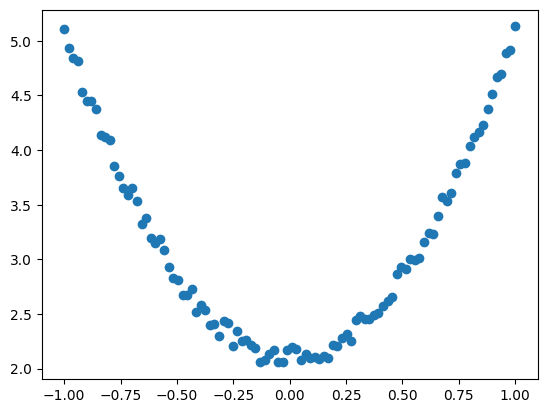

[[0.69012147]]


In [ ]:
# 1.导入库
import numpy as np
%matplotlib inline 
from matplotlib import pyplot as plt
# %matplotlib inline Jupyter专用命令：让图表直接在 notebook 中显示

# 2.生成输入数据及目标数据
np.random.seed(100)
x = np.linspace(-1, 1, 100).reshape(100, 1) # 从-1到1均匀取100个数，重新排列成100x1
y = 3*np.power(x, 2) + 2 + 0.2 * np.random.rand(x.size).reshape(100, 1)  # y = 3x^2 + 2
# np.random.rand(x.size) 生成x.size(100)个0-1之间随机小数

# 3.查看x、y数据分布情况
plt.scatter(x, y) # 绘制散点图
plt.show() # 显示图表

# 4.初始化权重参数
w1 = np.random.randn(1, 1)
b1 = np.random.randn(1, 1)

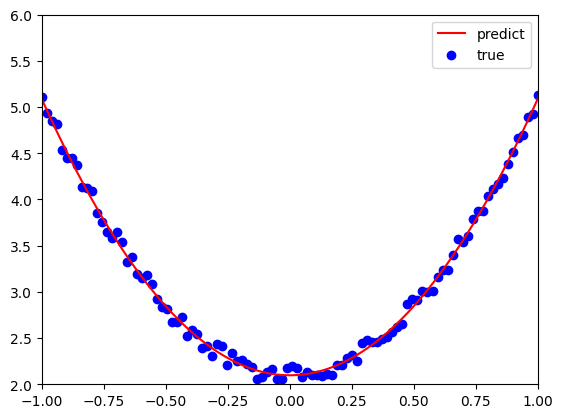

[[2.99133993]] [[2.09741845]]


In [ ]:
# 5.训练模型
lr = 0.001 # 学习率
for i in range(800):
    # 前向传播
    y_pred = np.power(x, 2) * w1 + b1
    loss = 0.5 * (y_pred - y) ** 2
    loss = loss.sum()
    # 计算梯度
    grad_w=np.sum((y_pred-y)*np.power(x,2))
    grad_b=np.sum((y_pred-y))
    # 使用梯度下降法
    w1 -= lr * grad_w
    b1 -= lr * grad_b

# 可视化结果

plt.plot(x, y_pred, 'r-', label='predict')
plt.scatter(x, y, color = 'blue', marker='o', label='true')
plt.xlim(-1, 1)
plt.ylim(2, 6)
plt.legend()
plt.show()
print(w1,b1)

## 2.7 使用Tensor及Autograd实现机器学习

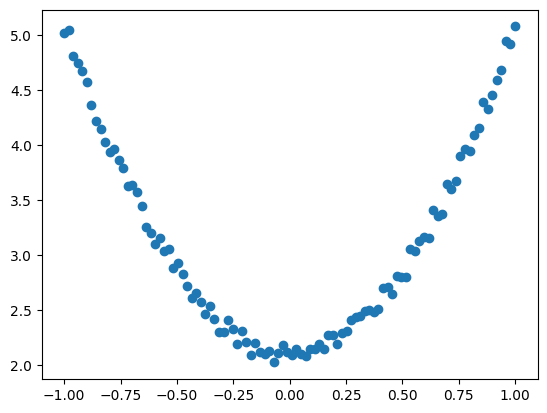

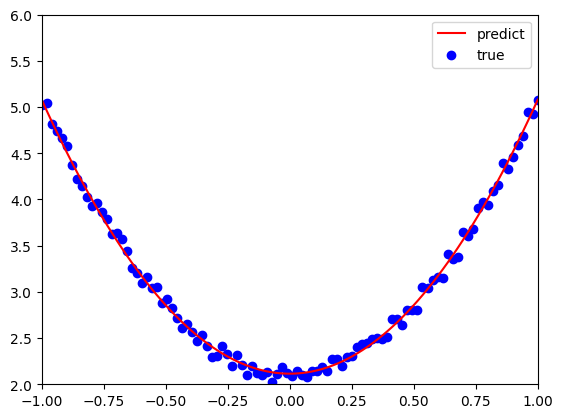

In [ ]:
# 导入库
import torch
%matplotlib inline
from matplotlib import pyplot as plt

# 生成训练数据
torch.manual_seed(100)
dtype = torch.float
# 生成x坐标数据
x = torch.unsqueeze(torch.linspace(-1,1,100),dim=1) # torch.linspace(-1,1,100)相当于创建了一个一维张量，再新添加一个维度
y = 3 * x.pow(2) +2 + 0.2 * torch.rand(x.size()) # x.pow(2)=(x)^2
# 画图
plt.scatter(x.numpy(), y.numpy())
plt.show()
# 初始化权重参数
w = torch.randn(1, 1, dtype=dtype, requires_grad=True)
b = torch.zeros(1, 1, dtype=dtype, requires_grad=True)

# 训练模型
lr = 0.001 # 学习率
for i in range(800):
    y_pred = x.pow(2).mm(w) + b
    loss = 0.5 * (y_pred - y) ** 2
    loss = loss.sum()
    # 自动计算梯度
    loss.backward() # 计算梯度
    # 手动更新参数，需要用torch.no_grad
    with torch.no_grad(): # 临时禁用所有张量的梯度计算
        w -= lr * w.grad
        b -= lr * b.grad
        # 梯度清零
        w.grad.zero_()
        b.grad.zero_() # 每次循环不清零则梯度累加

# 可视化训练结果
plt.plot(x.numpy(), y_pred.detach(), 'r-', label='predict') # 绘制模型的预测曲线
# y_pred带有梯度，matplotlib不识别，所以需要用.detach()分离梯度

plt.scatter(x.numpy(), y.numpy(), color='blue', marker='o', label='true') # matplotlib只用numpy数组，所以需要用x.numpy()将torch转换成numpy

plt.xlim(-1,1)
plt.ylim(2,6)
plt.legend() # 显示图例（predict / true 标签）
plt.show()

## 2.8 使用TensorFlow架构

In [ ]:
# 有兼容性问题，略过
import tensorflow as tf
import numpy as np

# 生成训练数据
np.random.seed(100)
x = np.linspace(-1, 1, 100).reshape(100, 1)
y = 3*np.power(x,2) + 2 + 0.2*np.random.rand(x.size).reshape(100,1)

# 初始化参数
x1 = tf.placeholder(tf.float32, shape=(None, 1))
y1 = tf.placeholder(tf.float32, shape=(None, 1))

# 创建权重变量w和b，并用随机值初始化
w = tf.Variable(tf.random_uniform([1], 0, 1.0))
b = tf.Variable(tf.zeros([1]))

# 前向传播
y_pred = np.power(x,2)*w + b

# 计算损失值
loss = tf.reduce_mean(tf.square(loss, [w, b]))

# 计算有关参数w、b关于损失函数的梯度
grad_w, grad_b = tf.gradients(loss, [w, b])

learning_rate = 0.01
new_w = w.assign(w - learning_rate * grad_w)
new_b = b.assign(b - learning_rate * grad_b)

# 训练模型
# ...


AttributeError: module 'tensorflow' has no attribute 'placeholder'